Libraries

In [1]:
! pip install brian2


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import brian2
from brian2 import *

import numpy as np
import matplotlib.pyplot as plt

# Задание

Смоделировать нейрон Leaky Integrate-and-Fire (описание нейрона, например, тут: https://neuronaldynamics.epfl.ch/online/Ch1.S3.html) с несколькими входными синапсами, на которые поступают пуассоновские последовательности спайков. Получить зависимость средней частоты выходных спайков нейрона от средней частоты входных спайков.

Параметры, задание нейрона и синапсов

In [4]:
start_scope()

tau_m = 10*ms #RC мембранная постоянная времени
v_rest = -70*mV
v_reset = -65*mV
v_threshold = -50*mV
t_ref = 2*ms

eqs = '''
dv/dt = (v_rest - v)/tau_m : volt (unless refractory)
'''
#тело нейрона
neuron = NeuronGroup(
    1, eqs, 
    threshold='v > v_threshold',
    reset='v = v_reset', 
    refractory=t_ref, 
    method='exact'
    )
neuron.v = v_rest

#пуассоновская последовательность
N = 100
rate = 15*Hz
P_group = PoissonGroup(N, rates=rate)

#синапсы
w = 1*mV

syn = Synapses(P_group, neuron, on_pre='v_post += w')
syn.connect()

WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (PlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


Запуск

In [5]:
mon_v = StateMonitor(neuron, 'v', record=True)
spikes_postsyn = SpikeMonitor(neuron)
spikes_presyn = SpikeMonitor(P_group)

run(1000*ms)

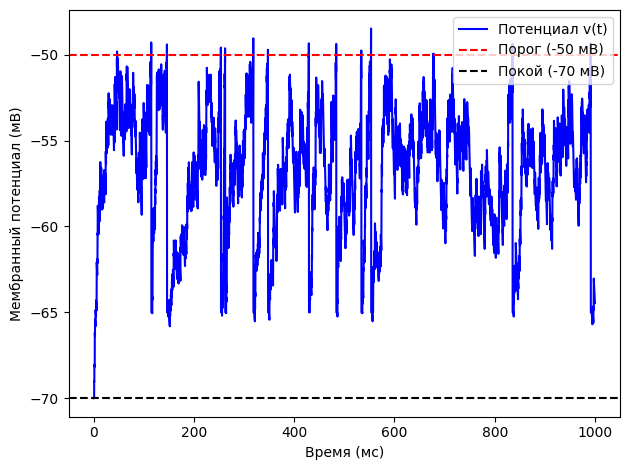

In [6]:
# мембранный потенциал постсинаптического нейрона
plt.plot(mon_v.t/ms, mon_v.v[0]/mV, label='Потенциал v(t)', color='blue')
plt.axhline(v_threshold/mV, color='red', linestyle='--', label='Порог (-50 мВ)')
plt.axhline(v_rest/mV, color='black', linestyle='--', label='Покой (-70 мВ)')
plt.xlabel('Время (мс)')
plt.ylabel('Мембранный потенциал (мВ)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Получение зависимости средней частоты выходных спайков нейрона от средней частоты входных спайков

In [7]:
input_rates = [1*Hz, 5*Hz, 10*Hz, 15*Hz, 20*Hz, 40*Hz, 50*Hz]
output_rates = []
run_time=2000*ms

eqs = '''
dv/dt = (v_rest - v)/tau_m : volt (unless refractory)
'''

for i in input_rates:
    start_scope()

    #тело нейрона
    neuron = NeuronGroup(
    1, eqs, 
    threshold='v > v_threshold',
    reset='v = v_reset', 
    refractory=t_ref, 
    method='exact'
    )
    neuron.v = v_rest

    #пуассоновская последовательность
    N = 100
    P_group = PoissonGroup(N, rates=i)

    #синапсы
    w = 1*mV
    syn = Synapses(P_group, neuron, on_pre='v_post += w')
    syn.connect()

    spikes = SpikeMonitor(neuron)

    run(run_time)

    rate_med = spikes.num_spikes / run_time
    output_rates.append(rate_med / Hz)


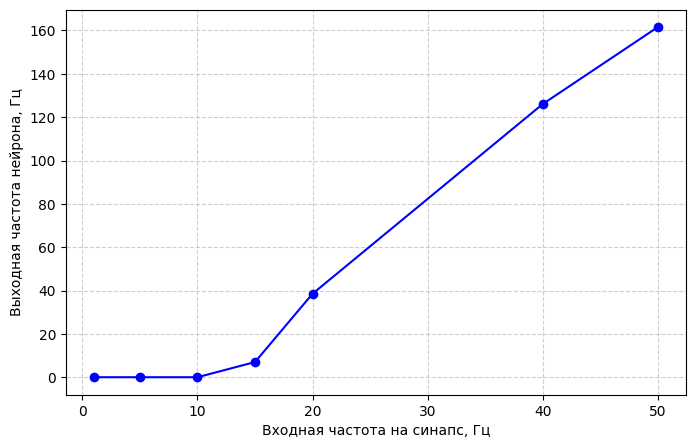

In [8]:

plt.figure(figsize=(8, 5))
plt.plot(input_rates / Hz, output_rates, 'o-', color='blue')
plt.xlabel('Входная частота на синапс, Гц')
plt.ylabel('Выходная частота нейрона, Гц')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Пластичность**

In [ ]:
tau_pre = 20*ms # время затухания пресинаптического следа
tau_post = 20*ms # время затухания постсинаптичеккого следа
w_max = 1*mV #вес
dApre = 0.01*w_max #STDP пре
dApost = -1.05*dApre*tau_pre/tau_post #STDP пост
input_rates_plast = [50*Hz]
run_time_plast = 100*second
eqs = '''
dv/dt = (v_rest - v)/tau_m : volt (unless refractory)
'''

for i in input_rates_plast:
    start_scope()

    #тело нейрона
    neuron = NeuronGroup(
    1, eqs, 
    threshold='v > v_threshold',
    reset='v = v_reset', 
    refractory=t_ref, 
    method='exact'
    )
    neuron.v = v_rest

    #пуассоновская последовательность
    N = 100
    P_group = PoissonGroup(N, rates=i)

    #синапсы
    syn_plast = Synapses(
    P_group, neuron,
    model='''
    w : volt
    dApre_trace/dt = -Apre_trace/tau_pre : volt (event-driven)
    dApost_trace/dt = -Apost_trace/tau_post : volt (event-driven)
    ''',
    #когда спайк на вход, проверяем был ли до него спайк на выход
    on_pre='''
    v_post += w
    Apre_trace += dApre
    w = clip(w + Apost_trace, 0*mV, w_max)
    ''',
    #когда спайк на выход, проверяем был ли до него спайк на вход
    on_post='''
    Apost_trace += dApost
    w = clip(w + Apre_trace, 0*mV, w_max)
    '''
    )

    syn_plast.connect()
    syn_plast.w = 'rand()*w_max' #наччальные веса

    spikes = SpikeMonitor(neuron)

    run(run_time_plast)
    final_weights = np.asarray(syn_plast.w/mV)
    rate_med = spikes.num_spikes / run_time
    output_rates.append(rate_med / Hz)


WARNING    'w' is an internal variable of group 'synapses', but also exists in the run namespace with the value 1. * mvolt. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


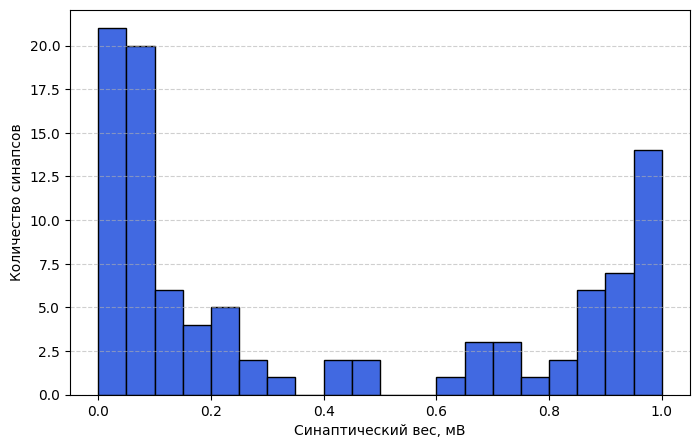

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(final_weights, bins=20, range=(0, w_max/mV),
         color='royalblue', edgecolor='black')
plt.xlabel('Синаптический вес, мВ')
plt.ylabel('Количество синапсов')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

большой вес=>сильный скачок потенциала=>вход чаще вызывает выходной спайк => вес увеличивается
маленький вес => малое влияние на нейрон => выходные спайки не зависят от него => вес уменьшается
из-за этого после обучения вес или большой или маленький

# Test 


One neuron

Text(0, 0.5, 'v')

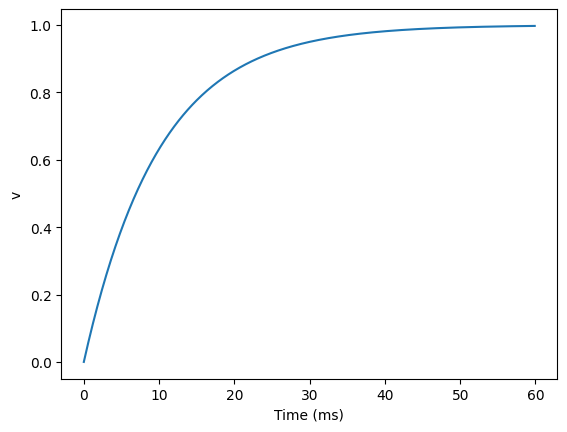

In [ ]:
start_scope()
tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, method='exact')
M = StateMonitor(G, 'v', record=True)

run(60*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v')

Spike times: [21.9 49.9] ms


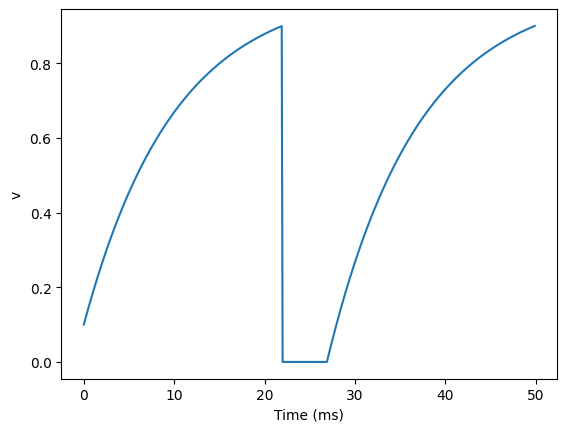

In [ ]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1 (unless refractory)
'''

G = NeuronGroup(1, eqs, threshold='v>0.9', reset='v = 0',refractory=5*ms, method='exact')
G.v = 0.1
M = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)
run(50*ms)
plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v')

print('Spike times: %s' % spikemon.t[:])

Multiple neurons

Text(0, 0.5, 'Neuron index')

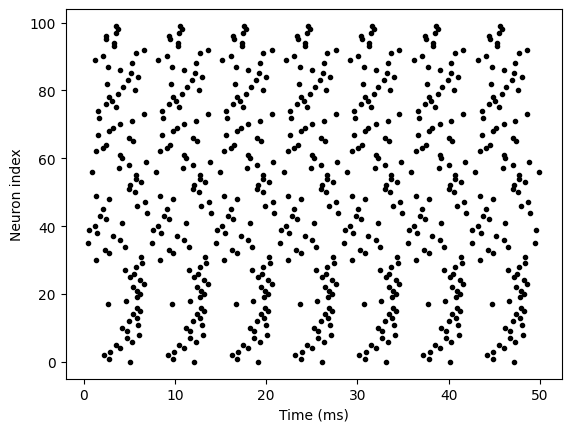

In [ ]:
start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'

spikemon = SpikeMonitor(G)

run(50*ms)

plot(spikemon.t/ms, spikemon.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')

WARNING    'i' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value 60. * hertz. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Text(0, 0.5, 'Firing rate (sp/s)')

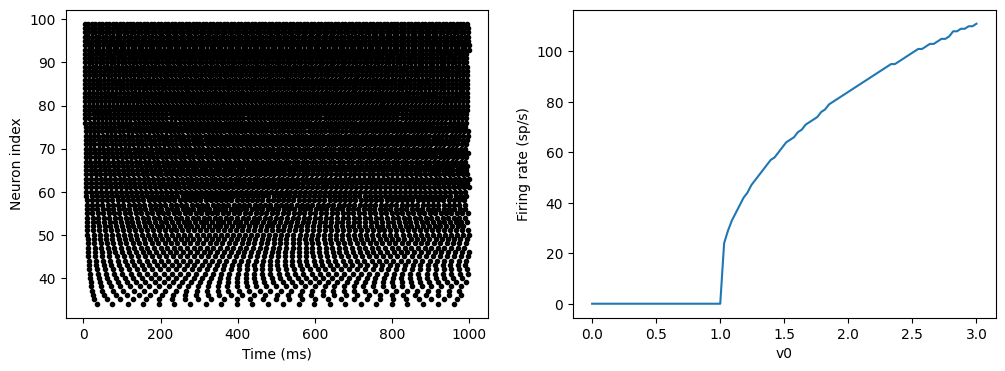

In [ ]:
start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms

eqs = '''
dv/dt = (v0-v)/tau : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='exact')
M = SpikeMonitor(G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(M.t/ms, M.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, M.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)')